In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
DATASET_PATH = "/content/drive/MyDrive/embroidery_dataset/originals"


In [3]:
import os

RESIZED_PATH = "/content/drive/MyDrive/embroidery_dataset/resized_768"
os.makedirs(RESIZED_PATH, exist_ok=True)


In [4]:
import cv2
from tqdm import tqdm

TARGET_SIZE = 768

for img_name in tqdm(os.listdir(DATASET_PATH)):
    if img_name.lower().endswith(('.jpg', '.png', '.jpeg', '.webp')):
        img_path = os.path.join(DATASET_PATH, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        resized = cv2.resize(
            img,
            (TARGET_SIZE, TARGET_SIZE),
            interpolation=cv2.INTER_LANCZOS4
        )

        save_path = os.path.join(RESIZED_PATH, img_name)
        cv2.imwrite(save_path, resized, [cv2.IMWRITE_JPEG_QUALITY, 95])


100%|██████████| 472/472 [03:11<00:00,  2.46it/s]


(np.float64(-0.5), np.float64(767.5), np.float64(767.5), np.float64(-0.5))

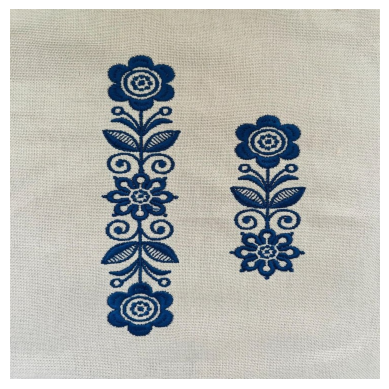

In [17]:
import matplotlib.pyplot as plt

sample_img = cv2.imread(os.path.join(RESIZED_PATH, os.listdir(RESIZED_PATH)[287]))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

plt.imshow(sample_img)
plt.axis("off")


In [18]:
BASE_SPLIT_PATH = "/content/drive/MyDrive/embroidery_dataset/splits"

for split in ["train_clean", "val_clean", "test_clean"]:
    os.makedirs(os.path.join(BASE_SPLIT_PATH, split), exist_ok=True)


In [19]:
import random
import shutil

random.seed(42)

images = os.listdir(RESIZED_PATH)
random.shuffle(images)

total = len(images)
train_end = int(0.8 * total)
val_end = int(0.9 * total)

splits = {
    "train_clean": images[:train_end],
    "val_clean": images[train_end:val_end],
    "test_clean": images[val_end:]
}

for split, img_list in splits.items():
    for img_name in img_list:
        src = os.path.join(RESIZED_PATH, img_name)
        dst = os.path.join(BASE_SPLIT_PATH, split, img_name)
        shutil.copy(src, dst)


In [20]:
for split in splits:
    print(split, ":", len(os.listdir(os.path.join(BASE_SPLIT_PATH, split))))


train_clean : 368
val_clean : 46
test_clean : 47
